## 1. Environment Setup

In [2]:
# Install required packages
!pip install xgboost lightgbm shap gseapy scikit-learn scipy seaborn matplotlib statsmodels -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 36.2 MB/s eta 0:00:00


In [3]:

# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Machine learning
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold, RepeatedStratifiedKFold, cross_val_score,
    train_test_split, permutation_test_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score,
    balanced_accuracy_score, matthews_corrcoef
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Explainability
import shap

# Pathway enrichment
import gseapy as gp

# Statistics
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All packages loaded successfully.")


All packages loaded successfully.


## 2. Mount Google Drive & Load Data

In [4]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive"

Mounted at /content/drive


In [5]:
# Load Open TG-GATEs data
expr = pd.read_csv(f"{BASE_DIR}/expression_matrix_gene1.csv", index_col=0)
meta = pd.read_csv(f"{BASE_DIR}/final_metadata.csv")
deg  = pd.read_csv(f"{BASE_DIR}/DEG_817.csv")

print(f"Expression matrix : {expr.shape}")
print(f"Metadata          : {meta.shape}")
print(f"DEG gene list     : {deg.shape}")

Expression matrix : (31099, 190)
Metadata          : (189, 24)
DEG gene list     : (817, 8)


## 3. Data Preprocessing

In [6]:
# Clean expression matrix: remove NA gene symbols, deduplicate, set index
expr = (
    expr
    .dropna(subset=["GeneSymbol"])
    .drop_duplicates(subset=["GeneSymbol"])
    .set_index("GeneSymbol")
    .drop(columns=["Unnamed: 0"], errors="ignore")
)

# Transpose: samples × genes
X = expr.T
print(f"Feature matrix (samples x genes): {X.shape}")

Feature matrix (samples x genes): (189, 14961)


In [7]:

# Filter to DEG genes available in expression matrix
deg_genes = deg["ID"].dropna().astype(str).unique().tolist()
available_genes = [g for g in deg_genes if g in X.columns]
X_deg = X[available_genes]

# Remove duplicated gene columns and force numeric values
X_deg = X_deg.loc[:, ~X_deg.columns.duplicated()].apply(pd.to_numeric, errors="coerce")
X_deg = X_deg.replace([np.inf, -np.inf], np.nan)

# Align labels to expression samples when a sample identifier column is available.
# If no explicit identifier is found, the notebook requires row order to match X.index.
sample_id_candidates = [
    "Sample", "SampleID", "Sample_ID", "sample", "sample_id",
    "GSM", "Array", "CEL", "ID", "Run"
]
label_col = "Label"
if label_col not in meta.columns:
    raise ValueError(f"Metadata must contain a '{label_col}' column. Found: {list(meta.columns)}")

matched_id_col = None
for col in sample_id_candidates:
    if col in meta.columns and set(X_deg.index).issubset(set(meta[col].astype(str))):
        matched_id_col = col
        break

if matched_id_col is not None:
    meta_aligned = meta.copy()
    meta_aligned[matched_id_col] = meta_aligned[matched_id_col].astype(str)
    meta_aligned = meta_aligned.set_index(matched_id_col).loc[X_deg.index]
else:
    if len(meta) != len(X_deg):
        raise ValueError(
            "Could not align metadata to expression samples: no matching sample ID column "
            f"and lengths differ (meta={len(meta)}, X={len(X_deg)})."
        )
    meta_aligned = meta.copy()
    meta_aligned.index = X_deg.index
    print("Warning: no explicit sample ID column found; assuming metadata row order matches expression columns.")

# Encode labels to 0/1 for scikit-learn/XGBoost while preserving the mapping for the manuscript.
y_raw = meta_aligned[label_col]
label_encoder = LabelEncoder()
y = pd.Series(label_encoder.fit_transform(y_raw), index=X_deg.index, name="Label")
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

if y.nunique() != 2:
    raise ValueError(f"Binary classification expected; found labels: {label_mapping}")

print(f"DEG genes available : {len(available_genes)}")
print(f"Feature matrix      : {X_deg.shape}")
print(f"Label mapping       : {label_mapping}")
print(f"Label distribution  :\n{y.value_counts().sort_index()}")


DEG genes available : 644
Feature matrix      : (189, 644)
Label mapping       : {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
Label distribution  :
Label
0    96
1    93
Name: count, dtype: int64


## 4. Feature Selection via Random Forest Importance

In [8]:

class TopNRandomForestSelector(BaseEstimator, TransformerMixin):
    """Leakage-safe top-N feature selector fitted inside each CV fold/training set."""

    def __init__(self, n_features=100, n_estimators=1000, random_state=42, n_jobs=-1):
        self.n_features = n_features
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.n_jobs = n_jobs

    def fit(self, X, y):
        X_df = pd.DataFrame(X).copy()
        self.feature_names_in_ = np.asarray(X_df.columns)
        self.imputer_values_ = X_df.median(numeric_only=True).reindex(X_df.columns).fillna(0.0)
        X_imp = X_df.fillna(self.imputer_values_)

        self.model_ = RandomForestClassifier(
            n_estimators=self.n_estimators,
            random_state=self.random_state,
            n_jobs=self.n_jobs,
            class_weight="balanced_subsample"
        )
        self.model_.fit(X_imp, y)
        importances = pd.Series(self.model_.feature_importances_, index=X_df.columns)
        n_keep = min(self.n_features, X_df.shape[1])
        self.selected_features_ = importances.sort_values(ascending=False).head(n_keep).index.tolist()
        self.importance_ = (
            importances.rename("Importance")
            .reset_index()
            .rename(columns={"index": "Gene"})
            .sort_values("Importance", ascending=False)
            .reset_index(drop=True)
        )
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        missing = [g for g in self.selected_features_ if g not in X_df.columns]
        if missing:
            raise ValueError(f"Selected features missing from transform data: {missing[:5]}")
        return X_df[self.selected_features_].fillna(self.imputer_values_[self.selected_features_])

feature_selector = TopNRandomForestSelector(
    n_features=100,
    n_estimators=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Defined leakage-safe RF selector. Feature selection will be fitted inside CV folds and on training data only.")


Defined leakage-safe RF selector. Feature selection will be fitted inside CV folds and on training data only.


## 5. Model Comparison — 5-Fold Stratified Cross-Validation

In [9]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
repeated_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=1000, random_state=RANDOM_STATE, n_jobs=-1,
        class_weight="balanced_subsample"
    ),
    "XGBoost": XGBClassifier(
        n_estimators=500, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, eval_metric="logloss"
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=500, learning_rate=0.05,
        random_state=RANDOM_STATE, verbose=-1, class_weight="balanced"
    ),
}

cv_results = {}
for name, model in models.items():
    pipe = Pipeline([
        ("select", TopNRandomForestSelector(n_features=100, random_state=RANDOM_STATE, n_jobs=-1)),
        ("model", model)
    ])
    scores = cross_val_score(pipe, X_deg, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:20s}  leakage-safe 5-fold AUC = {scores.mean():.4f} +/- {scores.std():.4f}")

# More stable estimate for the planned final model
xgb_pipe = Pipeline([
    ("select", TopNRandomForestSelector(n_features=100, random_state=RANDOM_STATE, n_jobs=-1)),
    ("model", XGBClassifier(
        n_estimators=500, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, eval_metric="logloss"
    ))
])
repeated_scores = cross_val_score(xgb_pipe, X_deg, y, cv=repeated_cv, scoring="roc_auc", n_jobs=-1)
print(f"\nXGBoost repeated 5x3 CV AUC = {repeated_scores.mean():.4f} +/- {repeated_scores.std():.4f}")


Random Forest         leakage-safe 5-fold AUC = 0.9403 +/- 0.0255
XGBoost               leakage-safe 5-fold AUC = 0.9479 +/- 0.0250
LightGBM              leakage-safe 5-fold AUC = 0.9379 +/- 0.0352

XGBoost repeated 5x3 CV AUC = 0.9493 +/- 0.0293


In [10]:
# Summary table
results_df = pd.DataFrame([
    {"Model": name, "AUC_mean": s.mean(), "AUC_std": s.std()}
    for name, s in cv_results.items()
]).sort_values("AUC_mean", ascending=False).reset_index(drop=True)

results_df

,Model,AUC_mean,AUC_std
0,XGBoost,0.947913,0.025021
1,Random Forest,0.940292,0.025504
2,LightGBM,0.937855,0.035160


## 6. Final XGBoost Model with Held-Out Test Set

In [11]:

# 80/20 stratified split on the full DEG matrix; feature selection is fitted on training data only.
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_deg, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

final_selector = TopNRandomForestSelector(
    n_features=100, n_estimators=1000, random_state=RANDOM_STATE, n_jobs=-1
)
X_train = final_selector.fit_transform(X_train_all, y_train)
X_test = final_selector.transform(X_test_all)

top100 = final_selector.importance_.head(100)
top100_genes = top100["GeneSymbol"].tolist()
X_top100 = X_deg[top100_genes]
top100.to_csv(f"{BASE_DIR}/Top100_Genes_training_only.csv", index=False)

# Fit final model on training set only
xgb_final = XGBClassifier(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, eval_metric="logloss"
)
xgb_final.fit(X_train, y_train)

y_pred_proba = xgb_final.predict_proba(X_test)[:, 1]
y_pred = xgb_final.predict(X_test)

auc_score = roc_auc_score(y_test, y_pred_proba)
bal_acc = balanced_accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)

print(f"Selected top-100 genes from training set only: {X_train.shape[1]}")
print(f"Hold-out Test AUC        : {auc_score:.4f}")
print(f"Balanced accuracy        : {bal_acc:.4f}")
print(f"Matthews corr. coefficient: {mcc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=[str(c) for c in label_encoder.classes_]))
top100.head(20)


Selected top-100 genes from training set only: 100
Hold-out Test AUC        : 0.9446
Balanced accuracy        : 0.9211
Matthews corr. coefficient: 0.8433

              precision    recall  f1-score   support

           0       0.90      0.95      0.92        19
           1       0.94      0.89      0.92        19

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



,GeneSymbol,Importance
0,Pla2g12a,0.023018
1,Guk1,0.020669
2,Rbbp8,0.019820
3,Rpl5,0.018451
4,Reep5,0.016960
5,Otc,0.016297
6,Abcb1b,0.015383
7,Gstz1,0.013975
8,Mmp12,0.013032
9,Arf3,0.012939


In [12]:

# Bootstrapped 95% CI for AUC
n_boot = 2000
boot_aucs = []
rng = np.random.default_rng(RANDOM_STATE)
y_test_arr = np.asarray(y_test)

for _ in range(n_boot):
    idx = rng.integers(0, len(y_test_arr), len(y_test_arr))
    if len(np.unique(y_test_arr[idx])) < 2:
        continue
    boot_aucs.append(roc_auc_score(y_test_arr[idx], y_pred_proba[idx]))

ci_low, ci_high = np.percentile(boot_aucs, [2.5, 97.5])
print(f"AUC = {auc_score:.4f}  (bootstrap 95% CI: {ci_low:.4f}-{ci_high:.4f}; {len(boot_aucs)} resamples)")

# Permutation test for model-level statistical significance.
# Keep n_permutations modest for runtime; increase to 1000 for final manuscript if compute allows.
perm_score, perm_scores, perm_pvalue = permutation_test_score(
    xgb_pipe, X_deg, y, scoring="roc_auc", cv=cv,
    n_permutations=100, n_jobs=-1, random_state=RANDOM_STATE
)
print(f"Permutation test AUC = {perm_score:.4f}; p = {perm_pvalue:.4g} (100 permutations)")


AUC = 0.9446  (bootstrap 95% CI: 0.8515-1.0000; 2000 resamples)
Permutation test AUC = 0.9479; p = 0.009901 (100 permutations)


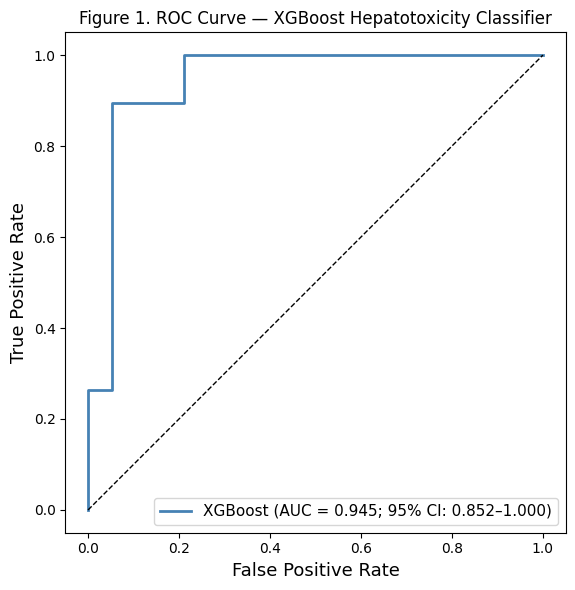

In [13]:
# ── Figure 1: ROC Curve ────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, lw=2, color="steelblue",
        label=f"XGBoost (AUC = {roc_auc:.3f}; 95% CI: {ci_low:.3f}–{ci_high:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate", fontsize=13)
ax.set_title("Figure 1. ROC Curve — XGBoost Hepatotoxicity Classifier", fontsize=12)
ax.legend(loc="lower right", fontsize=11)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("Figure1_ROC_XGBoost.png", dpi=300, bbox_inches="tight")
plt.show()

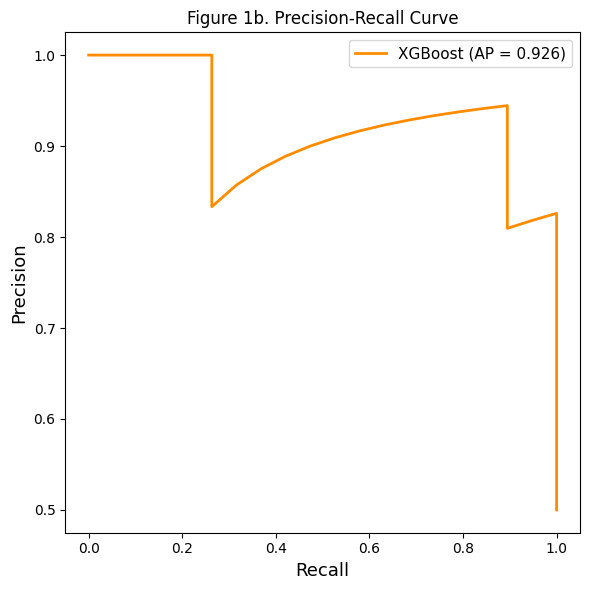

In [14]:
# ── Figure 1b: Precision-Recall Curve ─────────────────────────────────────────
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
ap_score = average_precision_score(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(recall, precision, lw=2, color="darkorange",
        label=f"XGBoost (AP = {ap_score:.3f})")
ax.set_xlabel("Recall", fontsize=13)
ax.set_ylabel("Precision", fontsize=13)
ax.set_title("Figure 1b. Precision-Recall Curve", fontsize=12)
ax.legend(loc="upper right", fontsize=11)
plt.tight_layout()
plt.savefig("Figure1b_PR_Curve.png", dpi=300, bbox_inches="tight")
plt.show()

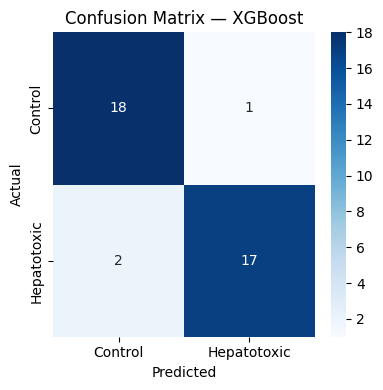

In [15]:
# ── Confusion Matrix ───────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Control", "Hepatotoxic"],
            yticklabels=["Control", "Hepatotoxic"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — XGBoost")
plt.tight_layout()
plt.savefig("Figure1c_Confusion_Matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Explainability — SHAP Analysis

> **Note on data leakage prevention:** SHAP values are computed on the **test set** only,
using the model trained exclusively on the training set.

In [16]:
# Compute SHAP values on the held-out test set (no leakage)
explainer   = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test)

# SHAP importance ranked
shap_importance = (
    pd.DataFrame({"Gene": X_test.columns, "SHAP": np.abs(shap_values).mean(axis=0)})
    .sort_values("SHAP", ascending=False)
    .reset_index(drop=True)
)
shap_importance.to_csv(f"{BASE_DIR}/Top_SHAP_Genes.csv", index=False)
shap_importance.head(20)

,Gene,SHAP
0,Cyp4b1,0.658155
1,Cited2,0.592981
2,Rbbp8,0.525054
3,Pla2g12a,0.407575
4,Reep5,0.319257
5,Cyp1a1,0.311182
6,Gadd45a,0.310371
7,Rhoc,0.293023
8,Slc2a5,0.263560
9,Gpx3,0.262901


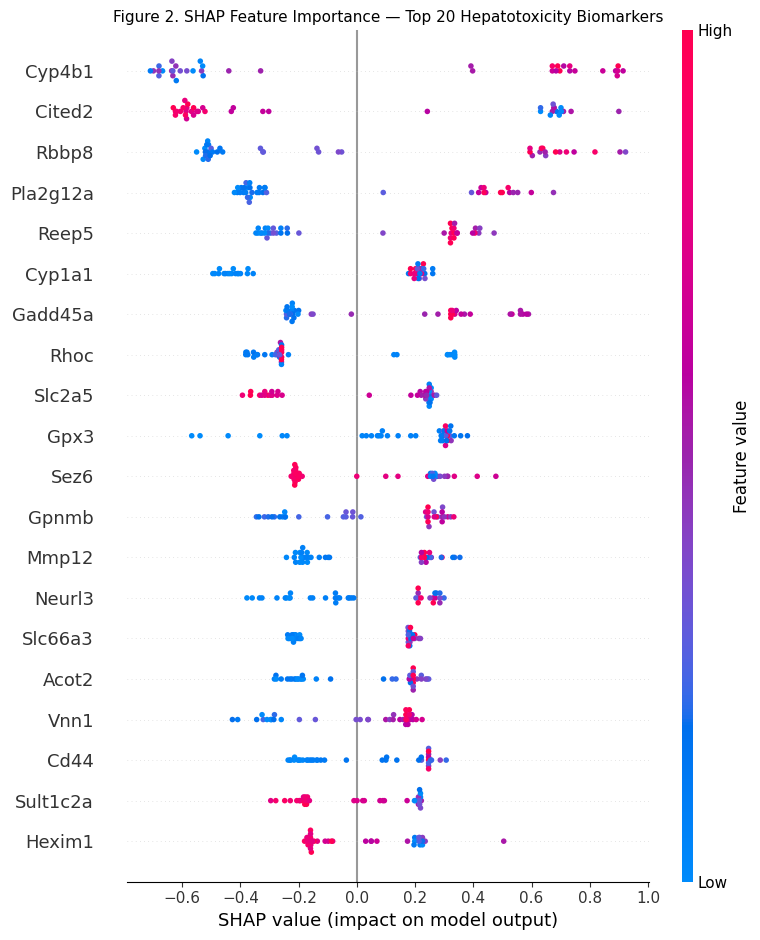

In [17]:
# ── Figure 2: SHAP Summary Plot ────────────────────────────────────────────────
shap.summary_plot(shap_values, X_test, max_display=20, show=False)
plt.title("Figure 2. SHAP Feature Importance — Top 20 Hepatotoxicity Biomarkers", fontsize=11)
plt.tight_layout()
plt.savefig("Figure2_SHAP_Summary.png", dpi=300, bbox_inches="tight")
plt.show()

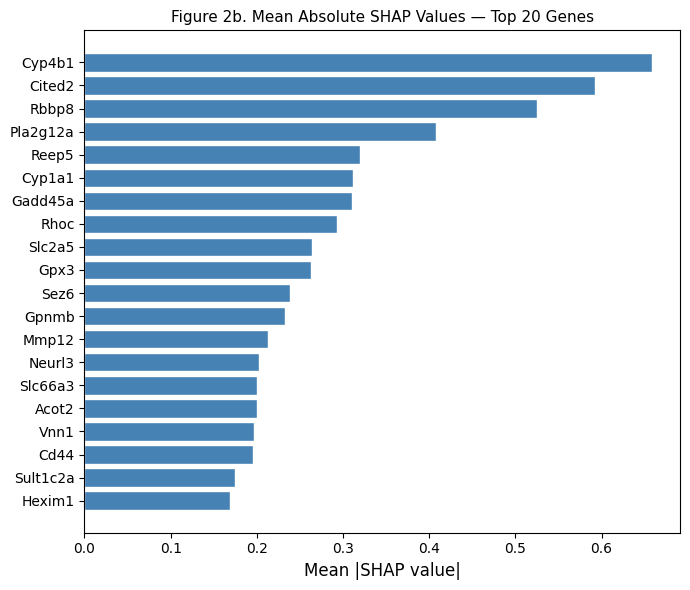

In [18]:
# ── Figure 2b: SHAP Bar Plot ───────────────────────────────────────────────────
top20_genes = shap_importance.head(20)["Gene"].tolist()

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top20_genes[::-1], shap_importance.head(20)["SHAP"].values[::-1],
        color="steelblue", edgecolor="white")
ax.set_xlabel("Mean |SHAP value|", fontsize=12)
ax.set_title("Figure 2b. Mean Absolute SHAP Values — Top 20 Genes", fontsize=11)
plt.tight_layout()
plt.savefig("Figure2b_SHAP_Bar.png", dpi=300, bbox_inches="tight")
plt.show()

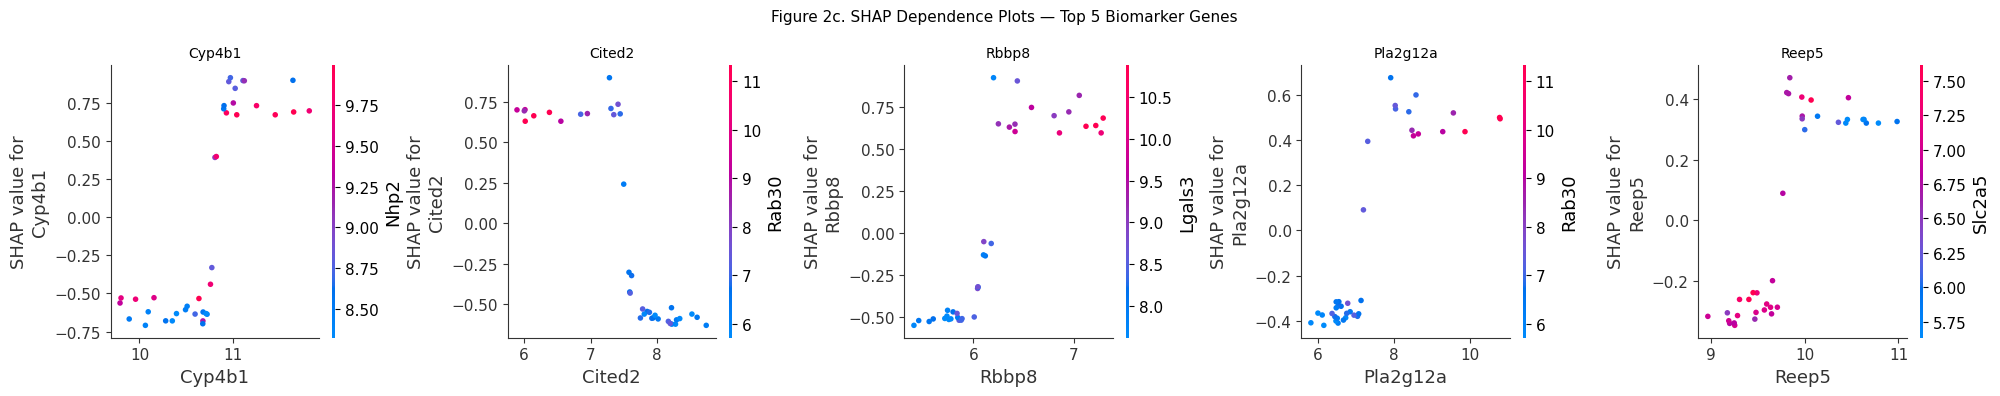

In [19]:
# ── Figure 2c: SHAP Dependence Plots for Top 5 Genes ──────────────────────────
top5_genes = shap_importance.head(5)["Gene"].tolist()

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, gene in enumerate(top5_genes):
    if gene in X_test.columns:
        gene_idx = list(X_test.columns).index(gene)
        shap.dependence_plot(gene_idx, shap_values, X_test,
                             ax=axes[i], show=False)
        axes[i].set_title(gene, fontsize=10)

plt.suptitle("Figure 2c. SHAP Dependence Plots — Top 5 Biomarker Genes", fontsize=11)
plt.tight_layout()
plt.savefig("Figure2c_SHAP_Dependence.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Pathway Enrichment Analysis (KEGG & GO-BP)

In [21]:
gene_list = top100["GeneSymbol"].drop_duplicates().tolist()

# KEGG enrichment
kegg_results = gp.enrichr(
    gene_list  = gene_list,
    gene_sets  = "KEGG_2021_Human",
    organism   = "human",
    outdir     = None
)
kegg_df = kegg_results.results
kegg_sig = kegg_df[kegg_df["Adjusted P-value"] < 0.05].sort_values("Adjusted P-value")

print(f"Significant KEGG pathways (adj. p < 0.05): {len(kegg_sig)}")
kegg_sig[["Term", "Overlap", "Adjusted P-value", "Genes"]].head(15)

Significant KEGG pathways (adj. p < 0.05): 1


,Term,Overlap,Adjusted P-value,Genes
0,Ovarian steroidogenesis,5/51,0.000796,ACOT2;AKR1C3;CYP1A1;ACOT1;IGF1


In [22]:
# GO Biological Process enrichment
go_results = gp.enrichr(
    gene_list  = gene_list,
    gene_sets  = "GO_Biological_Process_2025",
    organism   = "human",
    outdir     = None
)
go_df  = go_results.results
go_sig = go_df[go_df["Adjusted P-value"] < 0.05].sort_values("Adjusted P-value")

print(f"Significant GO-BP terms (adj. p < 0.05): {len(go_sig)}")
go_sig[["Term", "Overlap", "Adjusted P-value", "Genes"]].head(15)

Significant GO-BP terms (adj. p < 0.05): 8


,Term,Overlap,Adjusted P-value,Genes
0,Monocarboxylic Acid Metabolic Process (GO:0032...,8/127,0.000257,VNN1;ACOT2;CYP1A1;ANGPTL3;ACOT1;CYP4B1;ABAT;IGF1
1,Fatty Acid Metabolic Process (GO:0006631),6/130,0.025792,LIPC;ACOT2;CYP1A1;ANGPTL3;ACOT1;CYP4B1
2,Glycoprotein Catabolic Process (GO:0006516),3/19,0.039252,MMP12;MANBA;CTSL
3,Positive Regulation of Apoptotic Process (GO:0...,8/313,0.043099,LGALS3;TNFRSF12A;GADD45A;RACK1;AKR1C3;CCL2;GPL...
4,Sterol Metabolic Process (GO:0016125),4/58,0.043099,SULT1C3;CYP39A1;NSDHL;ANGPTL3
5,Lipid Metabolic Process (GO:0006629),7/259,0.044156,ACOT2;CYP1A1;ANGPTL3;AKR1C3;ACOT1;CYP4B1;PLPP2
6,"Wound Healing, Spreading of Cells (GO:0044319)",3/27,0.044156,MMP12;RHOC;CD44
7,Positive Regulation of Cell Migration (GO:0030...,8/344,0.044156,GPNMB;RACK1;ANGPTL3;CCL2;IGF1;RHOC;GPLD1;RHOB


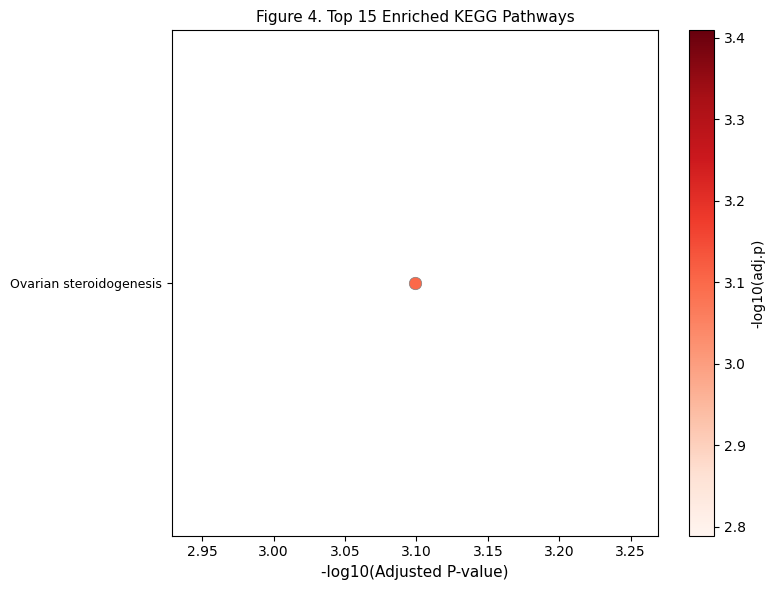

In [23]:
# ── Figure 4: Dot plot — Top 15 KEGG pathways ─────────────────────────────────
plot_kegg = kegg_sig.head(15).copy()

if not plot_kegg.empty:
    plot_kegg["-log10(adj.p)"] = -np.log10(plot_kegg["Adjusted P-value"].clip(lower=1e-300))

    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(
        plot_kegg["-log10(adj.p)"],
        range(len(plot_kegg)),
        c=plot_kegg["-log10(adj.p)"], cmap="Reds", s=80, edgecolors="grey", linewidths=0.5
    )
    ax.set_yticks(range(len(plot_kegg)))
    ax.set_yticklabels(plot_kegg["Term"].values, fontsize=9)
    ax.set_xlabel("-log10(Adjusted P-value)", fontsize=11)
    ax.set_title("Figure 4. Top 15 Enriched KEGG Pathways", fontsize=11)
    plt.colorbar(sc, ax=ax, label="-log10(adj.p)")
    plt.tight_layout()
    plt.savefig("Figure4_KEGG_Dotplot.png", dpi=300, bbox_inches="tight")
    plt.show()
elif kegg_sig.empty:
    print("No significant KEGG pathways found (adjusted p < 0.05).")
else:
    print("No KEGG pathways were available for plotting.")

## 9. External Validation — DrugMatrix (GSE57815)

In [24]:

import gzip

file_path = f"{BASE_DIR}/GSE57815_series_matrix.txt.gz"

# Extract sample titles
titles = None
with gzip.open(file_path, "rt", encoding="utf-8", errors="ignore") as f:
    for line in f:
        if line.startswith("!Sample_title"):
            titles = line.strip().split("\t")[1:]
            titles = [t.strip('"') for t in titles]
            break

# Load expression matrix (skip metadata lines starting with '!')
expr_dm = pd.read_csv(file_path, sep="\t", comment="!", index_col=0)
gsm_cols = [c for c in expr_dm.columns if str(c).startswith("GSM")]

if titles is None:
    raise ValueError("Could not find !Sample_title in the DrugMatrix series matrix file.")
if len(titles) != len(gsm_cols):
    raise ValueError(f"DrugMatrix title/sample mismatch: titles={len(titles)}, GSM columns={len(gsm_cols)}")

print(f"DrugMatrix expression: {expr_dm.shape}")
print(f"Sample titles found  : {len(titles)}")


DrugMatrix expression: (31099, 2218)
Sample titles found  : 2218


In [25]:

# Load GPL1355 probe annotation
annot = pd.read_csv(f"{BASE_DIR}/GPL1355_annotation.txt",
                    sep="\t", skiprows=16, low_memory=False)
annot_small = annot[["ID", "Gene Symbol"]].copy()
annot_small["Gene Symbol"] = annot_small["Gene Symbol"].astype(str).str.split("///").str[0].str.strip()
annot_small.loc[annot_small["Gene Symbol"].isin(["", "nan", "---"]), "Gene Symbol"] = np.nan

# Map probe IDs to gene symbols
expr_dm = expr_dm.reset_index()
expr_dm = expr_dm.merge(annot_small, left_on="ID_REF", right_on="ID", how="left")

expr_gene_dm = (
    expr_dm
    .dropna(subset=["Gene Symbol"])
    .set_index("Gene Symbol")
    .drop(columns=["ID_REF", "ID"], errors="ignore")
)

# Collapse duplicate probes by mean and force numeric values
expr_gene_dm = expr_gene_dm.apply(pd.to_numeric, errors="coerce")
expr_gene_dm = expr_gene_dm.groupby(expr_gene_dm.index).mean()

# Case-insensitive lookup for cross-species gene symbols where capitalization differs.
expr_gene_dm.index = expr_gene_dm.index.astype(str).str.strip()
gene_lookup_dm = {g.upper(): g for g in expr_gene_dm.index}

print(f"Gene-level expression (genes x samples): {expr_gene_dm.shape}")


Gene-level expression (genes x samples): (15119, 2218)


In [26]:

# Build metadata for DrugMatrix
meta_dm = pd.DataFrame({"GSM": gsm_cols, "Title": titles})

def extract_compound(title):
    parts = str(title).split("_")
    return parts[1].strip() if len(parts) >= 2 else None

meta_dm["Compound"] = meta_dm["Title"].apply(extract_compound)

# Assign labels: 1 = hepatotoxic positive controls; 0 = vehicle/control samples.
# Review this list against the exact DrugMatrix design before final submission.
toxic_compounds = ["CARBON TETRACHLORIDE", "CCL4", "THIOACETAMIDE", "METHAPYRILENE"]
control_patterns = ["_CMC_", "_VEHICLE_", "_CONTROL_"]

validation_meta = meta_dm.copy()
validation_meta["Label"] = np.nan
control_mask = validation_meta["Title"].str.contains("|".join(control_patterns), case=False, na=False)
toxic_mask = validation_meta["Compound"].str.upper().isin(toxic_compounds)
validation_meta.loc[control_mask, "Label"] = 0
validation_meta.loc[toxic_mask, "Label"] = 1

validation_meta = validation_meta[validation_meta["Label"].notna()].copy()
validation_meta["Label"] = validation_meta["Label"].astype(int)

print(f"Validation samples: {validation_meta.shape[0]}")
print(validation_meta["Label"].value_counts().sort_index())
print(validation_meta.groupby(["Label", "Compound"]).size().head(20))


Validation samples: 423
Label
0    393
1     30
Name: count, dtype: int64
Label  Compound                           
0      17-METHYLTESTOSTERONE                   6
       2,3,7,8-TETRACHLORODIBENZO-P-DIOXIN     9
       2-ACETYLAMINOFLUORENE                   3
       3-METHYLCHOLANTHRENE                    9
       AFLATOXIN B1                            6
       ALPHA-NAPHTHOFLAVONE                    3
       AMINOGLUTETHIMIDE                       3
       AMINOSALICYLIC ACID                     6
       AMIODARONE                              6
       ANASTROZOLE                             9
       ARTEMISININ                             9
       BETA-NAPHTHOFLAVONE                     9
       CARBAMAZEPINE                           9
       CHOLECALCIFEROL                         3
       CINNARIZINE                             3
       CLOMIPHENE                              6
       CLONAZEPAM                             12
       CLOSANTEL                               9
 

In [27]:

# External validation of pre-specified SHAP top-20 genes.
# Gene matching is case-insensitive; direction is estimated from discovery training data only.
top20 = shap_importance.head(20)["Gene"].tolist()

train_direction = {}
for gene in top20:
    if gene in X_train.columns:
        toxic_mean = X_train.loc[y_train == 1, gene].mean()
        control_mean = X_train.loc[y_train == 0, gene].mean()
        train_direction[gene] = 1 if toxic_mean >= control_mean else -1

control_samples = validation_meta.loc[validation_meta["Label"] == 0, "GSM"].tolist()
toxic_samples = validation_meta.loc[validation_meta["Label"] == 1, "GSM"].tolist()

val_results = []
mapped_panel_genes = []
for gene in top20:
    dm_gene = gene_lookup_dm.get(str(gene).upper())
    if dm_gene is None:
        continue

    ctrl = expr_gene_dm.loc[dm_gene, control_samples].astype(float).dropna().values
    toxic = expr_gene_dm.loc[dm_gene, toxic_samples].astype(float).dropna().values

    if len(ctrl) < 3 or len(toxic) < 3:
        continue

    stat, p = mannwhitneyu(ctrl, toxic, alternative="two-sided")
    delta_mean = toxic.mean() - ctrl.mean()
    direction_match = np.sign(delta_mean) == train_direction.get(gene, np.sign(delta_mean))
    mapped_panel_genes.append((gene, dm_gene, train_direction.get(gene, 1)))

    val_results.append({
        "Gene": gene,
        "DrugMatrixGene": dm_gene,
        "DiscoveryDirection": train_direction.get(gene, np.nan),
        "ControlMean": ctrl.mean(),
        "ToxicMean": toxic.mean(),
        "DeltaMean_ToxicMinusControl": delta_mean,
        "DirectionMatch": bool(direction_match),
        "Pvalue": p
    })

validation_results = pd.DataFrame(val_results).sort_values("Pvalue").reset_index(drop=True)

if len(validation_results):
    _, p_fdr, _, _ = multipletests(validation_results["Pvalue"], method="fdr_bh")
    _, p_bonf, _, _ = multipletests(validation_results["Pvalue"], method="bonferroni")
    validation_results["Pvalue_FDR_BH"] = p_fdr
    validation_results["Pvalue_bonferroni"] = p_bonf

validation_results.to_csv(f"{BASE_DIR}/External_Validation_Results.csv", index=False)

print(f"Top-20 SHAP genes mapped to DrugMatrix: {len(validation_results)}")
if len(validation_results):
    print(f"Significant after FDR BH q<0.05: {(validation_results['Pvalue_FDR_BH'] < 0.05).sum()}")
    print(f"Significant after Bonferroni p<0.05: {(validation_results['Pvalue_bonferroni'] < 0.05).sum()}")
validation_results.head(20)


Top-20 SHAP genes mapped to DrugMatrix: 19
Significant after FDR BH q<0.05: 17
Significant after Bonferroni p<0.05: 14


,Gene,DrugMatrixGene,DiscoveryDirection,ControlMean,ToxicMean,DeltaMean_ToxicMinusControl,DirectionMatch,Pvalue,Pvalue_FDR_BH,Pvalue_bonferroni
0,Neurl3,Neurl3,1,6.317410,8.253106,1.935696,True,2.244370e-17,4.264302e-16,4.264302e-16
1,Cd44,Cd44,1,5.151048,6.307046,1.155998,True,1.195113e-14,1.062647e-13,2.270716e-13
2,Mmp12,Mmp12,1,4.287684,6.199918,1.912234,True,1.677863e-14,1.062647e-13,3.187940e-13
3,Gpnmb,Gpnmb,1,7.895398,10.221514,2.326116,True,2.814967e-14,1.337109e-13,5.348437e-13
4,Acot2,Acot2,1,7.199815,8.562944,1.363129,True,7.728569e-14,2.936856e-13,1.468428e-12
5,Sez6,Sez6,-1,8.776942,6.665835,-2.111107,True,1.235796e-13,3.913355e-13,2.348013e-12
6,Reep5,Reep5,1,9.220508,10.303432,1.082923,True,2.330063e-12,6.324457e-12,4.427120e-11
7,Gadd45a,Gadd45a,1,8.476710,10.069064,1.592355,True,1.932568e-11,4.589849e-11,3.671879e-10
8,Rhoc,Rhoc,1,6.917427,7.436037,0.518610,True,4.439037e-11,9.371300e-11,8.434170e-10
9,Sult1c2a,Sult1c2a,-1,9.892477,8.903083,-0.989394,True,5.136009e-11,9.758416e-11,9.758416e-10


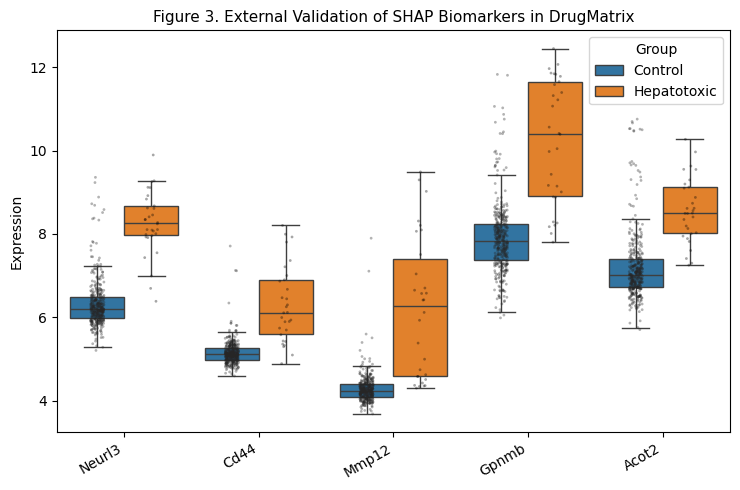

In [28]:

# Figure 3: boxplots of top externally validated biomarkers
if len(validation_results):
    top_validated = validation_results.sort_values("Pvalue_FDR_BH").head(5)["Gene"].tolist()
else:
    top_validated = []

plot_data = []
for gene in top_validated:
    dm_gene = gene_lookup_dm.get(str(gene).upper())
    if dm_gene is None:
        continue
    expr_vals = expr_gene_dm.loc[dm_gene, validation_meta["GSM"]].astype(float)
    tmp = pd.DataFrame({
        "Gene": gene,
        "Expression": expr_vals.values,
        "Group": validation_meta["Label"].map({0: "Control", 1: "Hepatotoxic"}).values
    })
    plot_data.append(tmp)

if plot_data:
    plot_df = pd.concat(plot_data, ignore_index=True)
    fig, ax = plt.subplots(figsize=(max(7, 1.5 * len(top_validated)), 5))
    sns.boxplot(data=plot_df, x="Gene", y="Expression", hue="Group", ax=ax, showfliers=False)
    sns.stripplot(data=plot_df, x="Gene", y="Expression", hue="Group", ax=ax,
                  dodge=True, color="black", alpha=0.35, size=2)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title="Group")
    ax.set_title("Figure 3. External Validation of SHAP Biomarkers in DrugMatrix", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Expression")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig("Figure3_External_Validation.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No mapped validation genes available for Figure 3.")


## 10. External Validation AUC — Biomarker Panel Score

DrugMatrix validation AUC (pre-specified signed SHAP panel, n=19 genes): 0.9622 (95% CI 0.9382-0.9807)


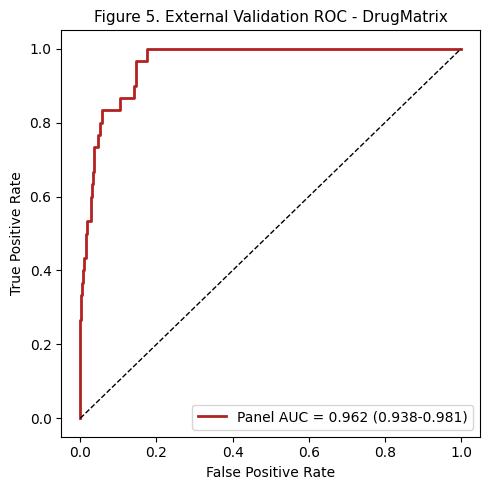

In [29]:

# External validation AUC using a pre-specified SHAP top-20 signed z-score panel.
# Genes are NOT selected by their DrugMatrix p-values, avoiding circular validation.
panel_info = mapped_panel_genes
if len(panel_info) >= 2:
    panel_genes = [dm_gene for _, dm_gene, _ in panel_info]
    panel_signs = pd.Series([direction for _, _, direction in panel_info], index=panel_genes)

    panel_expr = expr_gene_dm.loc[panel_genes, validation_meta["GSM"]].T.astype(float)
    panel_norm = (panel_expr - panel_expr.mean(axis=0)) / (panel_expr.std(axis=0) + 1e-9)
    panel_score = panel_norm.mul(panel_signs, axis=1).mean(axis=1)

    y_val = validation_meta["Label"].values
    val_auc = roc_auc_score(y_val, panel_score.values)

    # Bootstrap 95% CI for external validation AUC
    rng = np.random.default_rng(RANDOM_STATE)
    boot_val_aucs = []
    for _ in range(2000):
        idx = rng.integers(0, len(y_val), len(y_val))
        if len(np.unique(y_val[idx])) < 2:
            continue
        boot_val_aucs.append(roc_auc_score(y_val[idx], panel_score.values[idx]))
    val_ci_low, val_ci_high = np.percentile(boot_val_aucs, [2.5, 97.5])

    print(
        f"DrugMatrix validation AUC (pre-specified signed SHAP panel, n={len(panel_genes)} genes): "
        f"{val_auc:.4f} (95% CI {val_ci_low:.4f}-{val_ci_high:.4f})"
    )

    fpr_v, tpr_v, _ = roc_curve(y_val, panel_score.values)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(fpr_v, tpr_v, lw=2, color="firebrick",
            label=f"Panel AUC = {val_auc:.3f} ({val_ci_low:.3f}-{val_ci_high:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("Figure 5. External Validation ROC - DrugMatrix", fontsize=11)
    ax.legend()
    plt.tight_layout()
    plt.savefig("Figure5_Validation_ROC.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Not enough mapped SHAP genes for a pre-specified panel AUC. Showing individual gene AUCs:")
    for gene in validation_results.head(5)["Gene"] if len(validation_results) else []:
        dm_gene = gene_lookup_dm.get(str(gene).upper())
        if dm_gene is not None:
            scores = expr_gene_dm.loc[dm_gene, validation_meta["GSM"]].astype(float)
            gene_auc = roc_auc_score(validation_meta["Label"].values, scores.values)
            print(f"  {gene}: AUC = {gene_auc:.4f}")


## 11. Save All Outputs to Google Drive

In [30]:
import shutil, os

figures = [
    "Figure1_ROC_XGBoost.png",
    "Figure1b_PR_Curve.png",
    "Figure1c_Confusion_Matrix.png",
    "Figure2_SHAP_Summary.png",
    "Figure2b_SHAP_Bar.png",
    "Figure2c_SHAP_Dependence.png",
    "Figure3_External_Validation.png",
    "Figure4_KEGG_Dotplot.png",
    "Figure5_Validation_ROC.png",
]

for f in figures:
    if os.path.exists(f):
        shutil.copy(f, f"{BASE_DIR}/{f}")
        print(f"Saved: {f}")
    else:
        print(f"(skipped, not generated): {f}")

# Save tables
kegg_sig.to_csv(f"{BASE_DIR}/KEGG_Enrichment.csv", index=False)
go_sig.to_csv(f"{BASE_DIR}/GO_BP_Enrichment.csv", index=False)
shap_importance.to_csv(f"{BASE_DIR}/Top_SHAP_Genes.csv", index=False)
validation_results.to_csv(f"{BASE_DIR}/External_Validation_Results.csv", index=False)
results_df.to_csv(f"{BASE_DIR}/Model_Comparison_AUC.csv", index=False)

print("\nAll outputs saved to Google Drive.")

Saved: Figure1_ROC_XGBoost.png
Saved: Figure1b_PR_Curve.png
Saved: Figure1c_Confusion_Matrix.png
Saved: Figure2_SHAP_Summary.png
Saved: Figure2b_SHAP_Bar.png
Saved: Figure2c_SHAP_Dependence.png
Saved: Figure3_External_Validation.png
Saved: Figure4_KEGG_Dotplot.png
Saved: Figure5_Validation_ROC.png

All outputs saved to Google Drive.



## 12. Summary

| Component | Method | Output |
|---|---|---|
| Metadata/data integrity | Sample-label alignment, binary label encoding, missing-value handling | Auditable preprocessing |
| Feature selection | Random Forest top-100 fitted inside each CV fold and on training data only | Leakage-safe Top100 genes |
| Discovery model | RF, XGBoost, LightGBM with 5-fold CV; XGBoost repeated 5x3 CV | AUC mean +/- SD |
| Final internal validation | 80/20 stratified hold-out after training-only feature selection | AUC, 95% bootstrap CI, balanced accuracy, MCC |
| Statistical robustness | Permutation test for ROC-AUC | Empirical model-level p-value |
| Explainability | SHAP TreeExplainer on held-out test set only | Figure 2 summary/bar/dependence plots |
| Pathway enrichment | GSEApy Enrichr KEGG & GO-BP | Figure 4 |
| External validation | DrugMatrix GSE57815, case-insensitive gene mapping, Mann-Whitney U, FDR BH + Bonferroni | Figure 3 and validation table |
| External panel ROC | Pre-specified SHAP top-20 signed z-score panel; no selection by validation p-value | Figure 5 with bootstrap CI |

**Key strengths added for Q1 submission:** leakage-free feature selection, explicit label/sample alignment checks, repeated CV, bootstrap confidence intervals, permutation testing, non-circular external validation, multiple-testing correction, and interpretable biomarker prioritization.

**Important manuscript note:** Q1 acceptance is not guaranteed by code alone. The final paper should also include dataset accession details, sample inclusion/exclusion criteria, toxicant/control definition rationale, complete hyperparameter table, reproducibility environment, limitations on cross-species DrugMatrix validation, and biological discussion of top biomarkers/pathways.
